In [1]:
!pip install aenum lightly lightly-train ultralytics --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.6/863.6 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.4/714.4 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 58.7 MB/s eta 0:00:00


In [2]:
# ================================================================
# Kaggle Notebook: adapted for kidney_combined (YOLO labels present)
# ================================================================
# %% [setup]
import os, sys, json, math, random, shutil
from pathlib import Path
import numpy as np
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# -------------------------
# CONFIG: dataset locations
# -------------------------
BASE = Path("/kaggle/input/finalkidney/train")  # your Kaggle dataset root
IMAGES_DIR = BASE / "images"
LABELS_DIR = BASE / "labels"   # contains .txt YOLO labels
DATA_YAML_SOURCE = Path("/kaggle/input/finalkidney/data.yaml") # if provided; we'll overwrite working copy

# Output / working locations
WK = Path("/kaggle/working/")
YOLO_ROOT = WK / "kidney_combined_yolo"   # will host YOLO-ready dataset (train/val split)
YOLO_IMG_TRAIN = YOLO_ROOT / "images" / "train"
YOLO_IMG_VAL   = YOLO_ROOT / "images" / "val"
YOLO_LABEL_TRAIN = YOLO_ROOT / "labels" / "train"
YOLO_LABEL_VAL   = YOLO_ROOT / "labels" / "val"
YOLO_DATA_YAML = WK / "data.yaml"
RESULTS_DIR = WK / "yolo_results"
VIZ_DIR = WK / "viz_predictions"

for d in [YOLO_IMG_TRAIN, YOLO_IMG_VAL, YOLO_LABEL_TRAIN, YOLO_LABEL_VAL, RESULTS_DIR, VIZ_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -------------------------
# Basic checks
# -------------------------
assert IMAGES_DIR.exists(), f"Images folder not found: {IMAGES_DIR}"
assert LABELS_DIR.exists(), f"Label folder not found: {LABELS_DIR}"

# List images and matching labels
img_exts = {".jpg", ".jpeg", ".png", ".bmp"}
all_images = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in img_exts])
print(f"Found {len(all_images)} images in {IMAGES_DIR}")

# match labels by stem
images_with_label = []
images_without_label = []
for img in all_images:
    lbl = LABELS_DIR / f"{img.stem}.txt"
    if lbl.exists():
        images_with_label.append(img)
    else:
        images_without_label.append(img)

print(f"Images with label: {len(images_with_label)}  |  without label: {len(images_without_label)}")
if len(images_with_label) == 0:
    raise SystemExit("No YOLO .txt labels found in label/ — aborting.")

Found 3195 images in /kaggle/input/finalkidney/train/images
Images with label: 3195  |  without label: 0


In [3]:
# -------------------------
# Split train / val (80/20)
# -------------------------
from sklearn.model_selection import train_test_split
train_imgs, val_imgs = train_test_split(images_with_label, test_size=0.2, random_state=SEED, shuffle=True)

def copy_pairs(img_list, dst_img_dir, dst_label_dir):
    for img in img_list:
        dst_img = dst_img_dir / img.name
        src_label = LABELS_DIR / f"{img.stem}.txt"
        dst_label = dst_label_dir / src_label.name
        shutil.copy2(img, dst_img)
        shutil.copy2(src_label, dst_label)

copy_pairs(train_imgs, YOLO_IMG_TRAIN, YOLO_LABEL_TRAIN)
copy_pairs(val_imgs,   YOLO_IMG_VAL,   YOLO_LABEL_VAL)
print(f"Copied {len(train_imgs)} train and {len(val_imgs)} val images+labels into {YOLO_ROOT}")

# Optionally, copy unlabeled images into a separate folder for SSL (not used here)
if images_without_label:
    UNLABELED_DIR = WK / "unlabeled_kidney_images"
    UNLABELED_DIR.mkdir(parents=True, exist_ok=True)
    for img in images_without_label:
        shutil.copy2(img, UNLABELED_DIR / img.name)
    print(f"Copied {len(images_without_label)} unlabeled images to {UNLABELED_DIR}")

Copied 2556 train and 639 val images+labels into /kaggle/working/kidney_combined_yolo


Visualizing 6 train images with GT boxes...


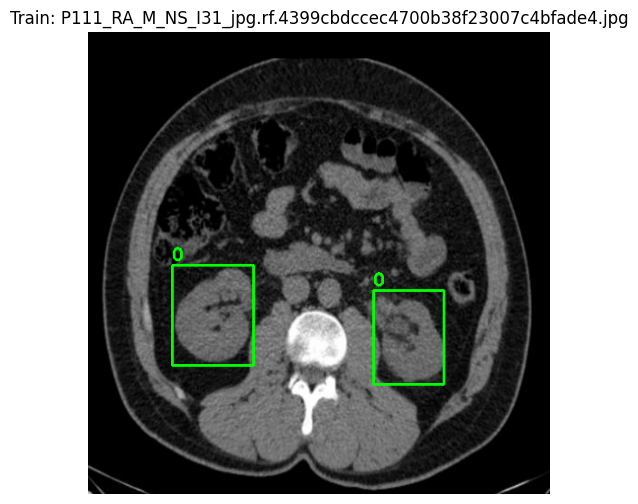

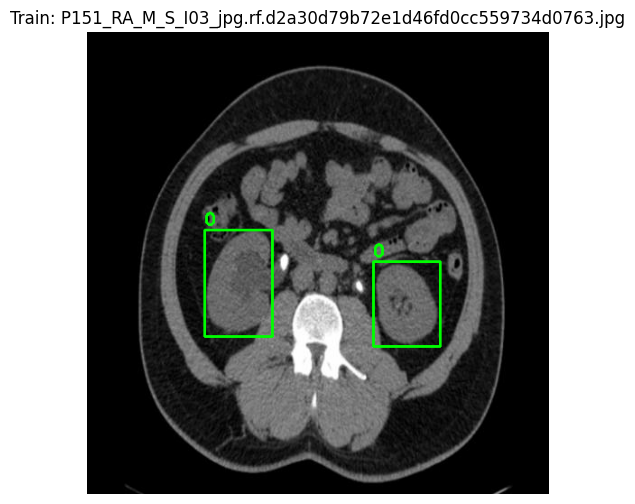

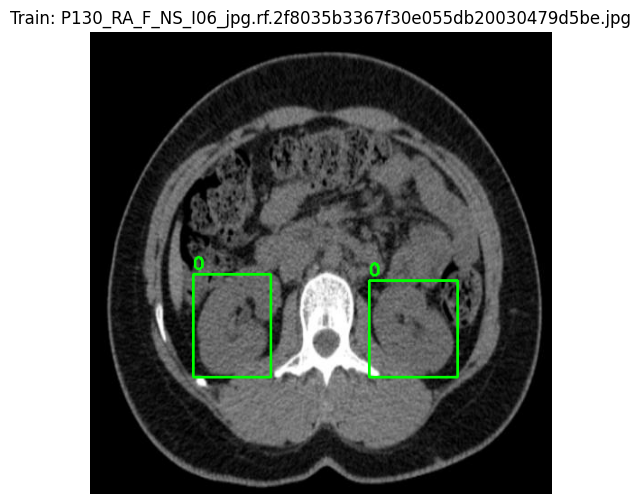

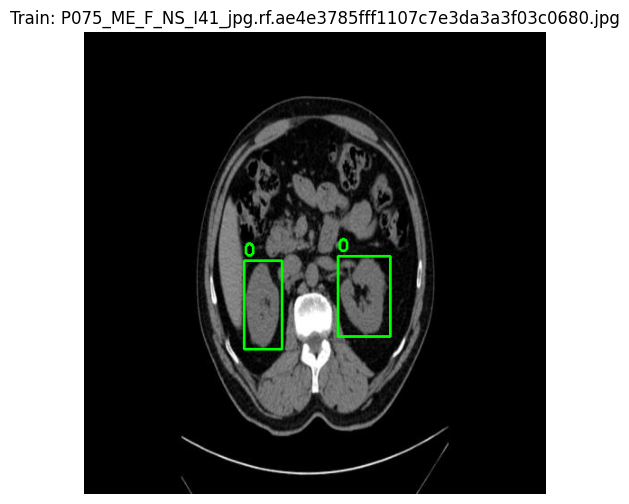

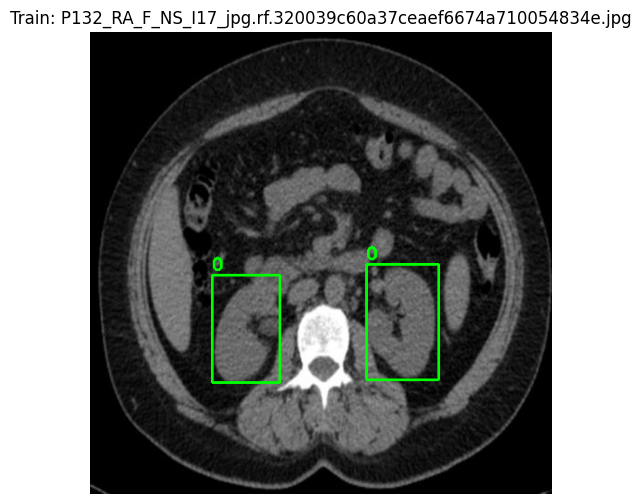

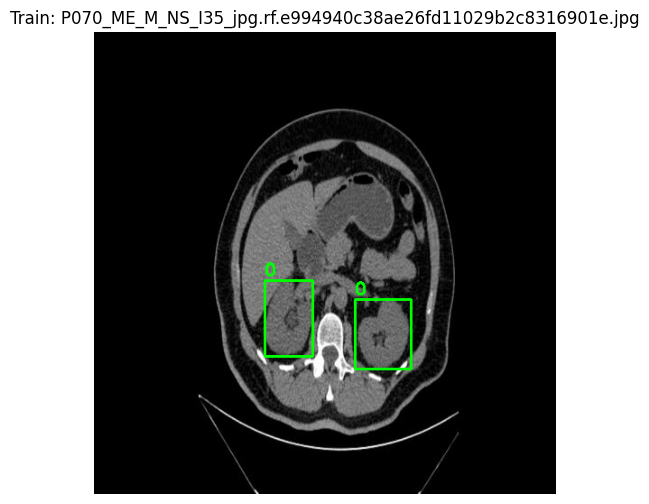

Train GT visualizations saved to: /kaggle/working/viz_predictions/train_bbox


In [4]:
# -------------------------
# Visualize TRAIN images with ground-truth YOLO boxes
# -------------------------
import cv2
import matplotlib.pyplot as plt

TRAIN_VIZ_DIR = VIZ_DIR / "train_bbox"
TRAIN_VIZ_DIR.mkdir(parents=True, exist_ok=True)

def yolo_to_xyxy(yolo_line, img_w, img_h):
    # yolo_line: class x_center y_center width height (normalized)
    parts = [float(x) for x in yolo_line.strip().split()]
    if len(parts) != 5:
        raise ValueError("Label must contain 5 values: cls xc yc w h")
    cls, xc, yc, w, h = parts

    x1 = (xc - w/2) * img_w
    y1 = (yc - h/2) * img_h
    x2 = (xc + w/2) * img_w
    y2 = (yc + h/2) * img_h
    return int(x1), int(y1), int(x2), int(y2), int(cls)

def draw_gt_boxes(img_path, label_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if label_path.exists():
        with open(label_path, "r") as f:
            for ln in f:
                if not ln.strip():
                    continue
                x1, y1, x2, y2, cls = yolo_to_xyxy(ln, w, h)

                # Draw in GREEN
                cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
                cv2.putText(img, str(cls), (x1, max(0, y1-6)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    return img


# ---------------------------------------------
# Load FIRST 6 images from TRAIN split only
# ---------------------------------------------
sample_train = list(YOLO_IMG_TRAIN.iterdir())[:6]

print(f"Visualizing {len(sample_train)} train images with GT boxes...")

for img_path in sample_train:
    label_path = YOLO_LABEL_TRAIN / f"{img_path.stem}.txt"

    img_vis = draw_gt_boxes(img_path, label_path)

    # save
    out_p = TRAIN_VIZ_DIR / f"{img_path.stem}_gt.png"
    cv2.imwrite(str(out_p), cv2.cvtColor(img_vis, cv2.COLOR_RGB2BGR))

    # show
    plt.figure(figsize=(8,6))
    plt.imshow(img_vis)
    plt.axis("off")
    plt.title(f"Train: {img_path.name}")
    plt.show()

print(f"Train GT visualizations saved to: {TRAIN_VIZ_DIR}")


OG

In [5]:
# ================================================
# Create correct data.yaml pointing to the working directory
# ================================================
YOLO_ROOT = Path("/kaggle/working/kidney_combined_yolo")

data_yaml_content = f"""
path: {YOLO_ROOT.absolute()}          # absolute path to dataset root
train: images/train                   # relative to path
val: images/val                       # relative to path

# Number of classes and class names (updated to match your dataset)
nc: 2
names: ['Normal', 'stone']

# Optional but recommended
download: false
"""

# Write to working directory
LABELED_YAML = "/kaggle/working/data.yaml"

with open(LABELED_YAML, "w") as f:
    f.write(data_yaml_content.strip())

print(f"✅ Created/updated data.yaml at: {LABELED_YAML}")
print("Content:")
print(data_yaml_content)

✅ Created/updated data.yaml at: /kaggle/working/data.yaml
Content:

path: /kaggle/working/kidney_combined_yolo          # absolute path to dataset root
train: images/train                   # relative to path
val: images/val                       # relative to path

# Number of classes and class names (updated to match your dataset)
nc: 2
names: ['Normal', 'stone']

# Optional but recommended
download: false



In [6]:
# ==============================================================
# DINOv3 SSL → YOLO Training Pipeline (Kidney Dataset)
# Single-config version - only DINOv3 distillation
# ==============================================================
!pip install --quiet lightly lightly-train ultralytics

import os, time, shutil, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO

# ==============================================================
# Utility Functions
# ==============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def subsample_unlabeled(src_dir: Path, dst_dir: Path, frac: float = 1.0):
    """Create a subset of unlabeled images (useful for quick testing)"""
    dst_dir.mkdir(parents=True, exist_ok=True)
    imgs = sorted([p for p in src_dir.glob("**/*") 
                   if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])
    
    if frac < 1.0:
        set_seed(0)
        keep = int(max(1, round(len(imgs) * frac)))
        imgs = imgs[:keep]
    
    for p in imgs:
        rel = p.relative_to(src_dir)
        (dst_dir / rel).parent.mkdir(parents=True, exist_ok=True)
        try:
            os.symlink(p, dst_dir / rel)
        except:
            shutil.copy2(p, dst_dir / rel)
    
    return len(imgs)

def find_ssl_weights(ssl_dir: Path):
    """Find the best or last checkpoint from lightly output"""
    cands = list(ssl_dir.rglob("*.pt"))
    if not cands:
        return None
    # Prefer best.pt > last.pt > anything else
    cands = sorted(cands, key=lambda p: (p.name != "best.pt", p.name != "last.pt"))
    return str(cands[0])

# ==============================================================
# DINOv3 Distillation + YOLO Fine-tune
# ==============================================================
def run_dinov3_pretrain(
    run_id: str,
    teacher_name: str,
    teacher_path: Path,
    unlabeled_dir: Path,
    epochs: int,
    batch_size: int,
    precision: str = "16-mixed"
):
    ssl_out = Path("/kaggle/working/dinov3_pretrain") / run_id
    if ssl_out.exists():
        shutil.rmtree(ssl_out)
    ssl_out.mkdir(parents=True, exist_ok=True)

    print(f"\n[DINOv3] Starting distillation pretraining: {run_id}")
    print(f"   → Output dir: {ssl_out}")
    print(f"   → Using teacher: {teacher_name}")

    try:
        import lightly_train
        lightly_train.train(
            out=str(ssl_out),
            data=str(unlabeled_dir),
            model="ultralytics/yolo11n.pt",          # ← backbone extracted from this
            method="distillation",
            method_args={
                "teacher": teacher_name,
                "teacher_url": str(teacher_path) if teacher_path.exists() else ""
            },
            epochs=epochs,
            batch_size=batch_size,
            precision=precision,
            overwrite=True,
            num_workers=0,                           # Kaggle friendly
        )
    except Exception as e:
        print(f"⚠️ DINOv3 pretraining failed: {e}")
        return None

    weights = find_ssl_weights(ssl_out)
    if weights:
        print(f"✅ DINOv3 SSL finished. Weights: {weights}")
    else:
        print("❌ No weights found in output directory!")
    
    return weights

def finetune_and_eval(run_id, init_weights, data_yaml, epochs=50, imgsz=512, device=None):
    """Train and evaluate YOLO — this part remains unchanged as requested"""
    out_dir = Path("/kaggle/working/yolo_results") / run_id
    if out_dir.exists():
        shutil.rmtree(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # Load model with SSL weights or fallback
    model = YOLO(init_weights if init_weights else "yolo11n.yaml")

    t0 = time.time()
    model.train(
        data=data_yaml,
        epochs=epochs,
        imgsz=imgsz,
        project=str(out_dir),
        name="train",
        device=device,
        save=True,
        exist_ok=True,
        verbose=True,
    )
    train_time = round(time.time() - t0, 2)

    # Validation
    metrics = model.val(
        data=data_yaml,
        project=str(out_dir),
        name="val",
        save=True,
        save_json=True,
        device=device
    )

    res = getattr(metrics, "results_dict", {})
    out = {
        "mAP50-95": res.get("metrics/mAP50-95(B)"),
        "mAP50":    res.get("metrics/mAP50(B)"),
        "precision": res.get("metrics/precision(B)"),
        "recall":   res.get("metrics/recall(B)"),
        "train_time_sec": train_time,
    }
    return out, str(out_dir)

# ==============================================================
# MAIN — Configuration (edit here only)
# ==============================================================
if __name__ == "__main__":
    # ── Your kidney dataset paths ──
    UNLABELED_DIR = Path("/kaggle/working/unlabeled_kidney_images")
    LABELED_YAML = "/kaggle/working/data.yaml"   # ← make sure this exists!
    
    # Teacher checkpoint (upload to Kaggle dataset)
    TEACHER_PATH = Path("/kaggle/input/dinov3/other/default/1/dinov3_vith16plus_lvd1689m.pth")
    # If your teacher is in different dataset → change path accordingly

    # ── Config ──
    CONFIG = {
        "run_id":           "kidney_dinov3_yolo11n",
        "teacher_name":     "dinov3/vith16plus",
        "unlabeled_frac":   1.0,          # set to 0.3~0.5 if memory/time is tight
        "ssl_epochs":       5,            # 3~10 reasonable on Kaggle
        "ssl_bs":           16,           # 32 may OOM → 16 is safer
        "finetune_epochs":  50,           # typical value for detection
        "precision":        "16-mixed",
    }

    # ── Execution ──
    set_seed(42)
    device = 0 if torch.cuda.is_available() else None

    # 1. Prepare unlabeled subset
    unl_subset = Path("/kaggle/working/ssl_subset_kidney")
    if unl_subset.exists():
        shutil.rmtree(unl_subset)
    
    nimgs = subsample_unlabeled(UNLABELED_DIR, unl_subset, CONFIG["unlabeled_frac"])
    print(f"[DATA] Using {nimgs} unlabeled kidney images for DINOv3 pretraining.")

    # 2. Run DINOv3 distillation
    ssl_weights = run_dinov3_pretrain(
        run_id=CONFIG["run_id"],
        teacher_name=CONFIG["teacher_name"],
        teacher_path=TEACHER_PATH,
        unlabeled_dir=unl_subset,
        epochs=CONFIG["ssl_epochs"],
        batch_size=CONFIG["ssl_bs"],
        precision=CONFIG["precision"],
    )

    # 3. Fine-tune YOLO
    if ssl_weights is None:
        print("⚠️ DINOv3 SSL failed → falling back to COCO-pretrained YOLO11n")
        ssl_weights = "yolo11n.pt"

    metrics, out_dir = finetune_and_eval(
        run_id=CONFIG["run_id"],
        init_weights=ssl_weights,
        data_yaml=LABELED_YAML,
        epochs=CONFIG["finetune_epochs"],
        imgsz=512,
        device=device,
    )

    # 4. Save results summary
    results_csv = Path("/kaggle/working/yolo_results/results_summary.csv")
    results_csv.parent.mkdir(exist_ok=True)
    
    df = pd.DataFrame([{**CONFIG, **metrics, "ssl_weights": ssl_weights, "out_dir": out_dir}])
    df.to_csv(results_csv, index=False)
    
    print("\n" + "="*60)
    print(" TRAINING COMPLETE ".center(60, "="))
    print("Results saved to:", results_csv)
    print(df.round(4))
    print("="*60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 4.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[DATA] Using 0 unlabeled kidney images for DINOv3 pretraining.

[DINOv3] Starting distillation pretraining: kidney_dinov3_yolo11n
   → Output dir: /kaggle/working/dinov3_pretrain/kidney_dinov3_yolo11n
   → Using teacher: dinov3/vith16plus


/usr/local/lib/python3.12/dist-packages/lightly_train/_commands/train.py:277: FutureWarning: `lightly_train.train` is deprecated and will be removed in a future release. Please use `lightly_train.pretrain` instead.
  train_from_config(config=config, called_via_train=True)

Args: {
    "accelerator": "auto",
    "batch_size": 16,
    "callbacks": null,
    "checkpoint": null,
    "data": "/kaggle/working/ssl_subset_kidney",
    "devices": "auto",
    "embed_dim": null,
    "epochs": 5,
    "float32_matmul_precision": "auto",
    "loader_args": null,
    "loggers": null,
    "method": "distillation",
    "method_args": {
        "teacher": "dinov3/vith16plus",
        "teacher_url": "/kaggle/input/dinov3/other/default/1/dinov3_vith16plus_lvd1689m.pth"
    },
    "model": "ultralytics/yolo11n.pt",
    "model_args": null,
    "num_nodes": 1,
    "num_workers": 0,
    "optim": "auto",
    "optim_args": null,
    "out": "/kaggle/working/dinov3_pretrain/kidney_dinov3_yolo11n",
    "overwrite"

⚠️ DINOv3 pretraining failed: Data directory '/kaggle/working/ssl_subset_kidney' is empty!
⚠️ DINOv3 SSL failed → falling back to COCO-pretrained YOLO11n
Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mos